# Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [25]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline

# Modelling
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor


#### Import the CSV Data as Pandas DataFrame

In [50]:
df = pd.read_csv('./data/stud.csv')

#### Show Top 5 Records

In [51]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Columns

In [52]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

#### Preparing X and Y variables

In [53]:
X = df.drop(columns=['math_score'])
y = df['math_score']

In [54]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [55]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [56]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

### Create Column Transformer with 3 types of transformers

In [57]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [58]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

oh_transformer = OneHotEncoder()
num_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    [
        ("StandardScaler",num_transformer,num_features),
        ("OneHotEncoder",oh_transformer,cat_features)
    ]
)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4948\1613034994.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include='object').columns


In [59]:
X = preprocessor.fit_transform(X)

In [60]:
X.shape

(1000, 19)

## separate dataset into train and test

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [62]:
def model_evaluation(y_test,y_pred):
    rmse  = root_mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    r2score = r2_score(y_test,y_pred)
    return rmse,mae,r2score

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_score_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    # Train model
    model.fit(X_train,y_train)

    # Make Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Evaluate Train and Test data
    train_rmse,train_mae,train_r2score = model_evaluation(y_train,y_pred_train)
    test_rmse,test_mae,test_r2score = model_evaluation(y_test,y_pred_test)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for train data : ")
    print("Root Mean Squared Error -- {:.4f}".format(train_rmse))
    print("Mean absolute Error -- {:.4f}".format(train_mae))
    print("R_2 score -- {:.4f}".format(train_r2score))

    print("----------------------------------------------------")

    print("Model Performance for test data : ")
    print("Root Mean Squared Error -- {:.4f}".format(test_rmse))
    print("Mean absolute Error -- {:.4f}".format(test_mae))
    print("R_2 score -- {:.4f}".format(test_r2score))
    r2_score_list.append(test_r2score)
    
    print("="*35)
    print('\n')



Linear Regression
Model Performance for train data : 
Root Mean Squared Error -- 5.3231
Mean absolute Error -- 4.2667
R_2 score -- 0.8743
----------------------------------------------------
Model Performance for test data : 
Root Mean Squared Error -- 5.3940
Mean absolute Error -- 4.2148
R_2 score -- 0.8804


Lasso
Model Performance for train data : 
Root Mean Squared Error -- 6.5938
Mean absolute Error -- 5.2063
R_2 score -- 0.8071
----------------------------------------------------
Model Performance for test data : 
Root Mean Squared Error -- 6.5197
Mean absolute Error -- 5.1579
R_2 score -- 0.8253


Ridge
Model Performance for train data : 
Root Mean Squared Error -- 5.3233
Mean absolute Error -- 4.2650
R_2 score -- 0.8743
----------------------------------------------------
Model Performance for test data : 
Root Mean Squared Error -- 5.3904
Mean absolute Error -- 4.2111
R_2 score -- 0.8806


K-Neighbors Regressor
Model Performance for train data : 
Root Mean Squared Error -- 5.7

## RESULTS

In [64]:
pd.DataFrame(list(zip(model_list, r2_score_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.852935
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.850447
1,Lasso,0.825320
6,XGBRegressor,0.821221
3,K-Neighbors Regressor,0.783770
4,Decision Tree,0.762861


## Linear Regression

In [65]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 88.04


## Plot y_pred and y_test

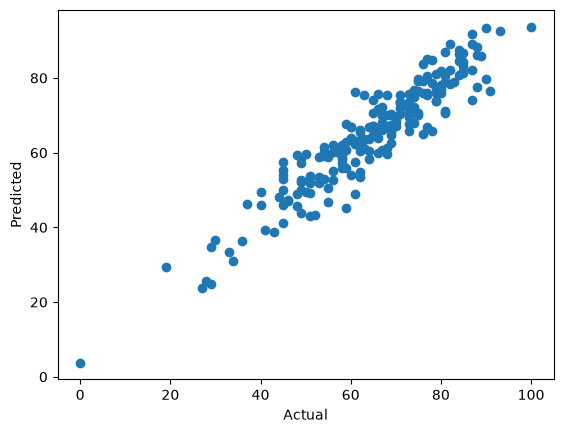

In [66]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

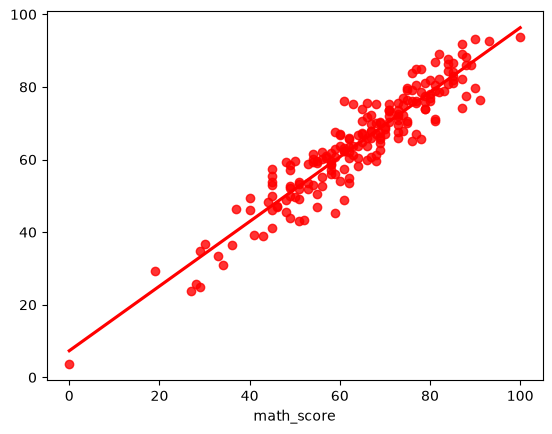

In [67]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

#### Difference between Actual and Predicted Values

In [68]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
